###  Fashion MNIST Classifier
### Clothing Item Classification using Artificial Neural Network

Import Libraries


In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" All libraries imported successfully!")

 All libraries imported successfully!


Load & Preprocess Dataset


In [3]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Preprocessing
train_images = train_images / 255.0
test_images = test_images / 255.0

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples: {train_images.shape[0]}")
print(f"Test samples: {test_images.shape[0]}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000


Data Visualization


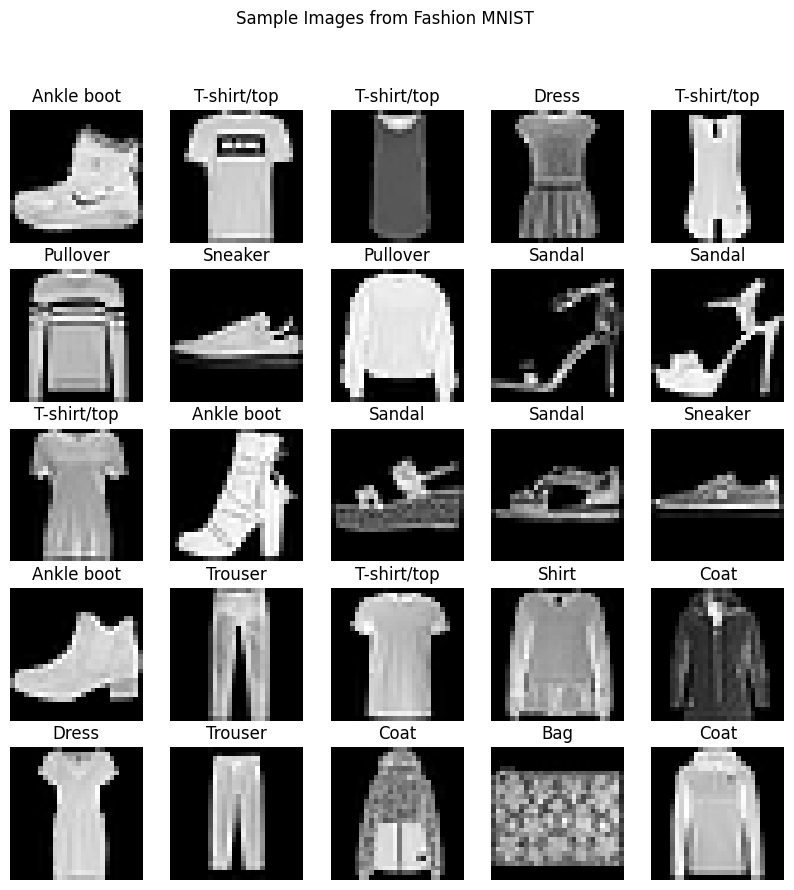

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.suptitle("Sample Images from Fashion MNIST")
plt.show()

Build Model


In [10]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [6]:
history = model.fit(train_images, train_labels,
                    epochs=10,
                    validation_split=0.1,
                    batch_size=32)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7702 - loss: 0.6487 - val_accuracy: 0.8525 - val_loss: 0.4211
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8355 - loss: 0.4668 - val_accuracy: 0.8577 - val_loss: 0.3819
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8452 - loss: 0.4321 - val_accuracy: 0.8497 - val_loss: 0.3995
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8542 - loss: 0.4080 - val_accuracy: 0.8733 - val_loss: 0.3642
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8583 - loss: 0.3950 - val_accuracy: 0.8718 - val_loss: 0.3474
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8643 - loss: 0.3771 - val_accuracy: 0.8760 - val_loss: 0.3394
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8662 - loss: 0.3718 - val_accuracy: 0.8752 - val_loss: 0.3382
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8677 - loss: 0.3623 

 Evaluation & Chart

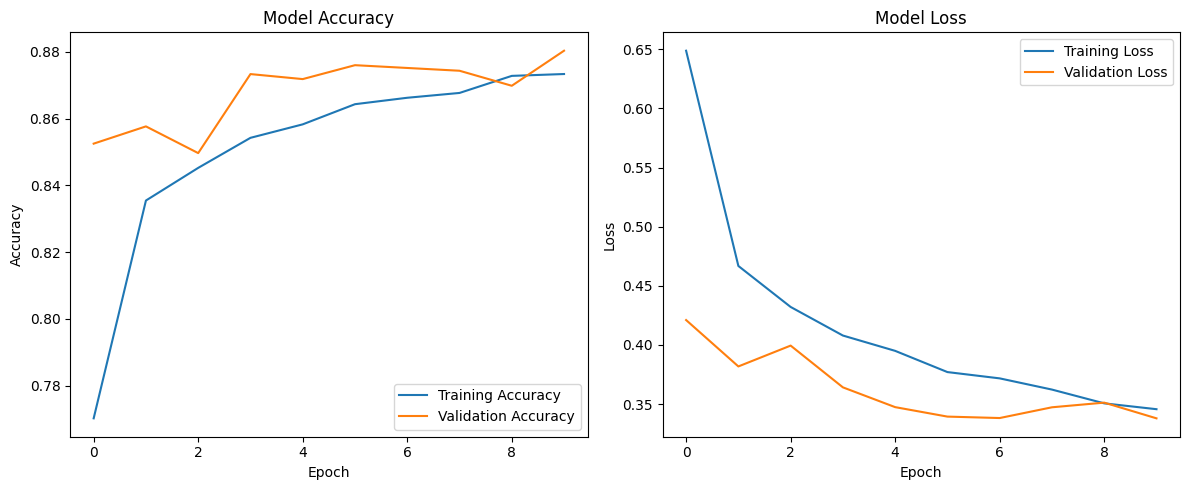

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8693 - loss: 0.3648

🎉 Test Accuracy: 86.93%


In [7]:
# Accuracy & Loss Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Final Evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\n🎉 Test Accuracy: {test_acc*100:.2f}%")

Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


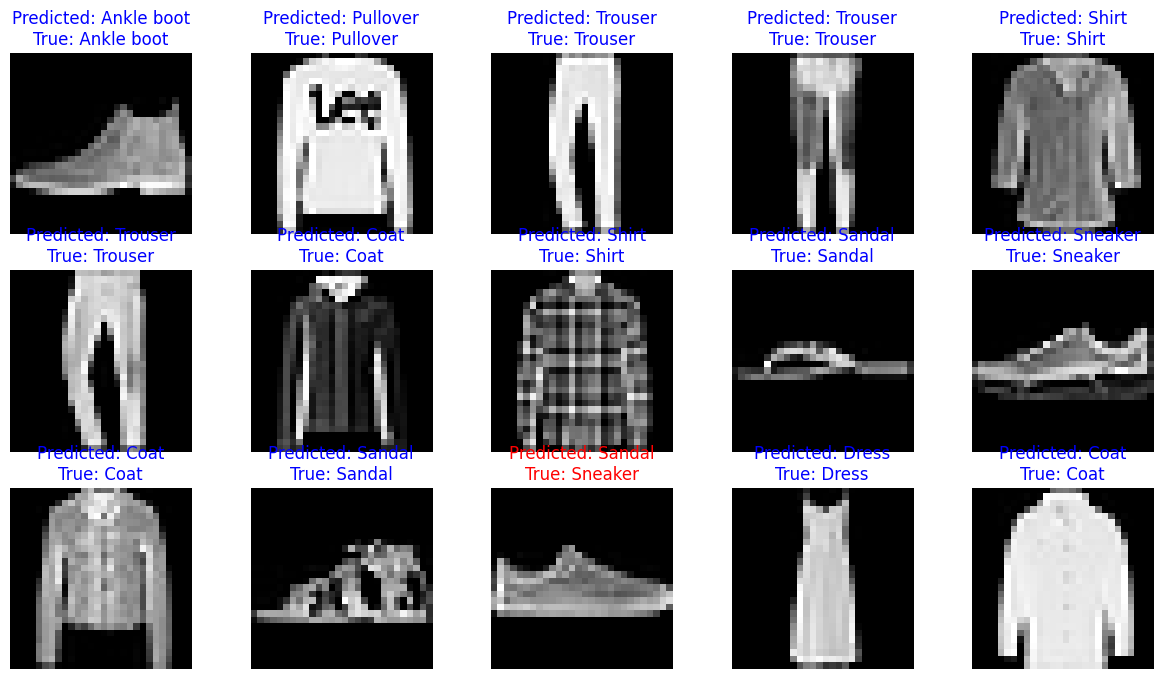

In [8]:
predictions = model.predict(test_images)

def plot_prediction(i):
    plt.imshow(test_images[i], cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    color = 'blue' if pred_label == true_label else 'red'
    plt.title(f"Predicted: {class_names[pred_label]}\nTrue: {class_names[true_label]}", color=color)
    plt.axis('off')

plt.figure(figsize=(15,8))
for i in range(15):
    plt.subplot(3,5,i+1)
    plot_prediction(i)
plt.show()

Project Extensions (Future Work)


In [9]:
print("🚀 Project Extensions & Future Improvements\n")

extensions = [
    "1. Use Convolutional Neural Network (CNN) → Accuracy 92%+",
    "2. Apply Data Augmentation (rotation, zoom, flip)",
    "3. Hyperparameter Tuning using Keras Tuner",
    "4. Transfer Learning (MobileNet, ResNet50)",
    "5. Build Web App using Gradio or Streamlit",
    "6. Real-time classification using Webcam",
    "7. Model Deployment on Cloud (TensorFlow Serving / Hugging Face)",
    "8. Ensemble Learning (combine multiple models)"
]

for ext in extensions:
    print(ext)

🚀 Project Extensions & Future Improvements

1. Use Convolutional Neural Network (CNN) → Accuracy 92%+
2. Apply Data Augmentation (rotation, zoom, flip)
3. Hyperparameter Tuning using Keras Tuner
4. Transfer Learning (MobileNet, ResNet50)
5. Build Web App using Gradio or Streamlit
6. Real-time classification using Webcam
7. Model Deployment on Cloud (TensorFlow Serving / Hugging Face)
8. Ensemble Learning (combine multiple models)
